ALGERIAN FOREST FIRES DATASET 
The dataset include 244 instances that groiped a data of a two region of algerai the bejaia region located in the northeast algeria and the sisi bel abbes located in the northwest of algeria 

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline


In [5]:
df=pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv',header=1)

FileNotFoundError: [Errno 2] No such file or directory: 'Algerian_forest_fires_dataset_UPDATE.csv'

In [ ]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [ ]:
## in this dataset all the things are the object we first need to convert that into the integers 
df[df['day']=='Sidi-Bel Abbes Region Dataset']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


DATA CLEANING


In [ ]:
## now we will divide the dataset into two region 
df.loc[:122,'region']=0
df.loc[122:,'region']=1

In [ ]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1.0
242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1.0
243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1.0
244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1.0


In [ ]:
 ## Nowwe will remove the missing NAN values 
df[df.isnull().any(axis=1)]


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1.0


In [ ]:
df = df.drop(df[df.isnull().any(axis=1)].index)

In [ ]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
region         0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    object 
 1   month        244 non-null    object 
 2   year         244 non-null    object 
 3   Temperature  244 non-null    object 
 4    RH          244 non-null    object 
 5    Ws          244 non-null    object 
 6   Rain         244 non-null    object 
 7   FFMC         244 non-null    object 
 8   DMC          244 non-null    object 
 9   DC           244 non-null    object 
 10  ISI          244 non-null    object 
 11  BUI          244 non-null    object 
 12  FWI          244 non-null    object 
 13  Classes      244 non-null    object 
 14  region       244 non-null    float64
dtypes: float64(1), object(14)
memory usage: 30.5+ KB


In [ ]:
df.dropna().reset_index

<bound method DataFrame.reset_index of     day month  year Temperature  RH  Ws Rain   FFMC  DMC    DC  ISI   BUI  \
0    01    06  2012          29  57  18     0  65.7  3.4   7.6  1.3   3.4   
1    02    06  2012          29  61  13   1.3  64.4  4.1   7.6    1   3.9   
2    03    06  2012          26  82  22  13.1  47.1  2.5   7.1  0.3   2.7   
3    04    06  2012          25  89  13   2.5  28.6  1.3   6.9    0   1.7   
4    05    06  2012          27  77  16     0  64.8    3  14.2  1.2   3.9   
..   ..   ...   ...         ...  ..  ..   ...   ...  ...   ...  ...   ...   
241  26    09  2012          30  65  14     0  85.4   16  44.5  4.5  16.9   
242  27    09  2012          28  87  15   4.4  41.1  6.5     8  0.1   6.2   
243  28    09  2012          27  87  29   0.5  45.9  3.5   7.9  0.4   3.4   
244  29    09  2012          24  54  18   0.1  79.7  4.3  15.2  1.7   5.1   
245  30    09  2012          24  64  15   0.2  67.3  3.8  16.5  1.2   4.8   

     FWI     Classes    region  
0  

In [ ]:
df[df['day']=='day']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
123,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1.0


In [ ]:
## now we will drop this column
df.drop(123,inplace=True)

In [ ]:
df.dropna().reset_index

<bound method DataFrame.reset_index of     day month  year Temperature  RH  Ws Rain   FFMC  DMC    DC  ISI   BUI  \
0    01    06  2012          29  57  18     0  65.7  3.4   7.6  1.3   3.4   
1    02    06  2012          29  61  13   1.3  64.4  4.1   7.6    1   3.9   
2    03    06  2012          26  82  22  13.1  47.1  2.5   7.1  0.3   2.7   
3    04    06  2012          25  89  13   2.5  28.6  1.3   6.9    0   1.7   
4    05    06  2012          27  77  16     0  64.8    3  14.2  1.2   3.9   
..   ..   ...   ...         ...  ..  ..   ...   ...  ...   ...  ...   ...   
241  26    09  2012          30  65  14     0  85.4   16  44.5  4.5  16.9   
242  27    09  2012          28  87  15   4.4  41.1  6.5     8  0.1   6.2   
243  28    09  2012          27  87  29   0.5  45.9  3.5   7.9  0.4   3.4   
244  29    09  2012          24  54  18   0.1  79.7  4.3  15.2  1.7   5.1   
245  30    09  2012          24  64  15   0.2  67.3  3.8  16.5  1.2   4.8   

     FWI     Classes    region  
0  

In [ ]:
## converting all the numerric in the integer and the float 

for col in df.columns:
    if col != df.columns[-2]:
        df[col] = pd.to_numeric(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4    RH          243 non-null    int64  
 5    Ws          243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  region       243 non-null    float64
dtypes: float64(8), int64(6), object(1)
memory usage: 30.4+ KB


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df['Classes'].unique()

array(['not fire   ', 'fire   ', 'fire', 'fire ', 'not fire', 'not fire ',
       'not fire     ', 'not fire    '], dtype=object)

In [ ]:
## here we are replaaing the extra space so our feature has only two values 

df['Classes'] = df['Classes'].str.strip()
df['Classes'] = df['Classes'].str.replace(" ", "")

In [ ]:
df['Classes'].unique()

array(['notfire', 'fire'], dtype=object)

In [ ]:
## now we will chamge the fire and not fire with 0 and 1 
df['Classes']=df['Classes'].replace(
    {
        'notfire':0,
        'fire':1
        
    }
)

C:\Users\saini\AppData\Local\Temp\ipykernel_5088\104229001.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Classes']=df['Classes'].replace(


In [ ]:
df['Classes'].unique()

array([0, 1])

In [ ]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.563786,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.496938,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,1.000000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000,1.000000


EDA 


In [ ]:
# make a copy of the dataset 

df_copy=df.drop(['day','month','year'],axis=1,inplace=True)

In [ ]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
241,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1.0
242,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1.0
243,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1.0
244,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1.0


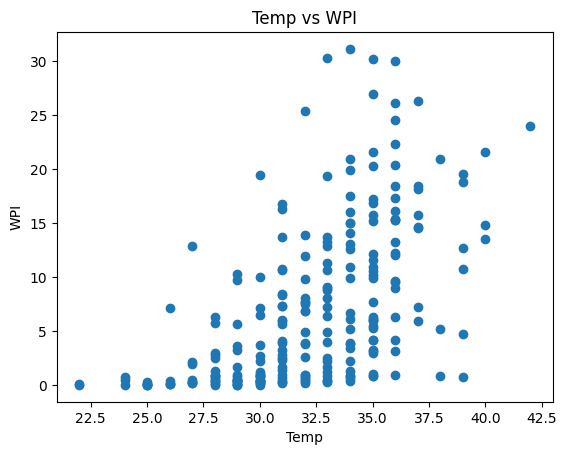

In [ ]:
## NOW WE VISULAIZATION USING THE MATPLOTLIB
plt.scatter(df['Temperature'], df['FWI'])

plt.xlabel('Temp')
plt.ylabel('WPI')
plt.title('Temp vs WPI')

plt.show()

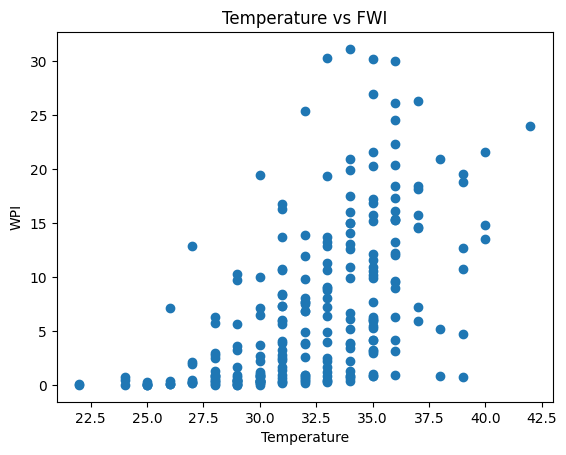

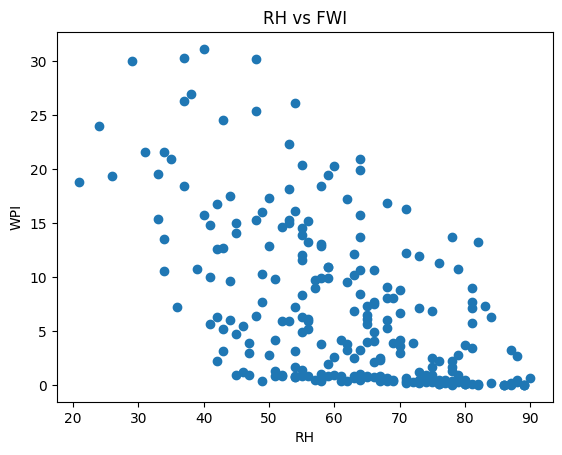

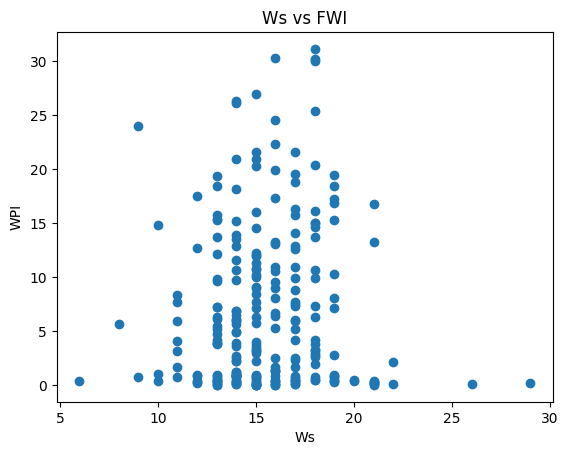

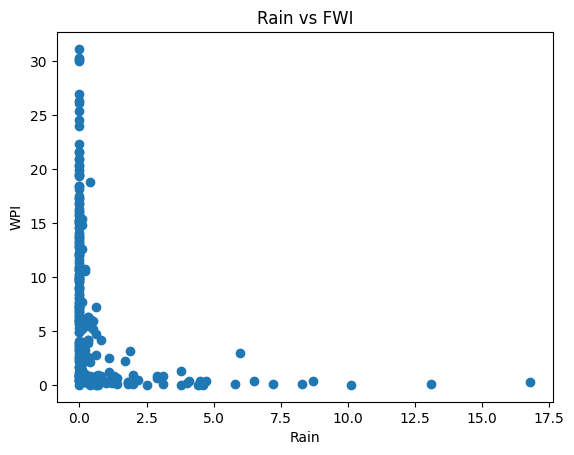

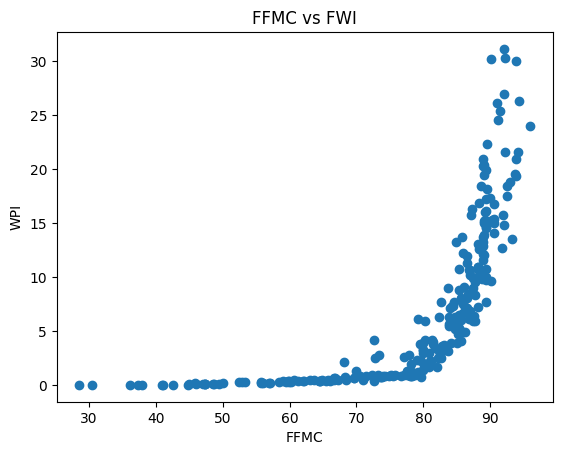

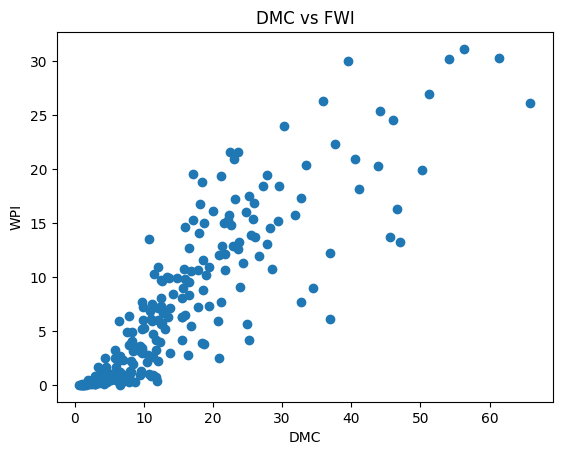

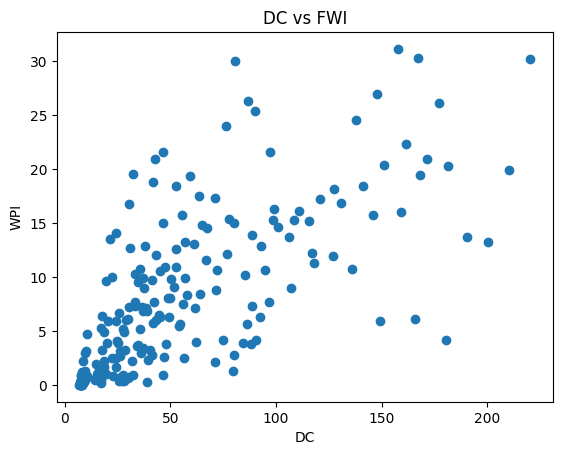

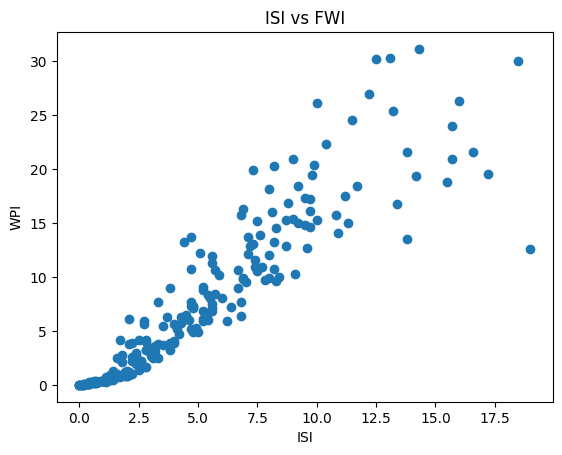

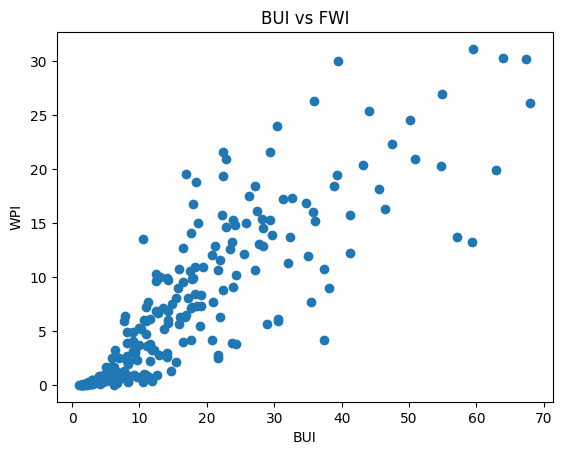

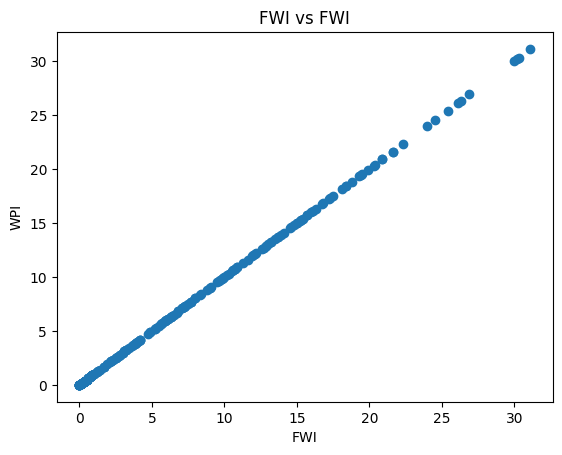

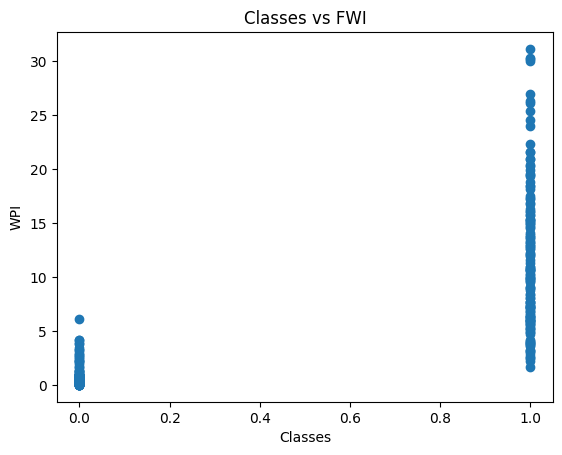

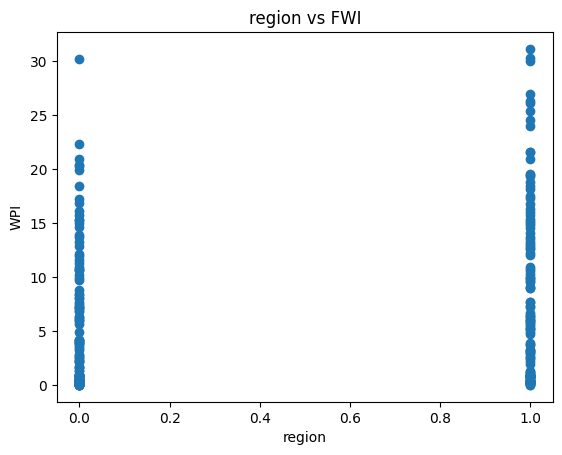

In [ ]:
## now checking the relation of all the feature with the ouput 


for col in df.columns:
    if col != 'WPI':
        plt.scatter(df[col], df['FWI'])
        plt.xlabel(col)
        plt.ylabel('WPI')
        plt.title(f'{col} vs FWI')
        plt.show()

In [ ]:
## checking the coreealtion and the covariacne of all the feature 
print(df.corr()['FWI'])
print(df.cov()['FWI'])


Temperature    0.566670
RH            -0.580957
Ws             0.032368
Rain          -0.324422
FFMC           0.691132
DMC            0.875864
DC             0.739521
ISI            0.922895
BUI            0.857973
FWI            1.000000
Classes        0.719216
region         0.197102
Name: FWI, dtype: float64
Temperature     15.297068
RH             -64.096917
Ws               0.677079
Rain            -4.835502
FFMC            73.791799
DMC             80.764530
DC             262.277746
ISI             28.526552
BUI             90.831493
FWI             55.362048
Classes          2.659303
region           0.734784
Name: FWI, dtype: float64


ANALYSIS 
1: Temperature is directly corrated and having small cova
2:

In [ ]:
## PERCENTAGE FOR PIE CHART 
df['Classes'].value_counts(normalize=True)*100

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

In [ ]:
corr_matrix = df.corr()
corr_matrix

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


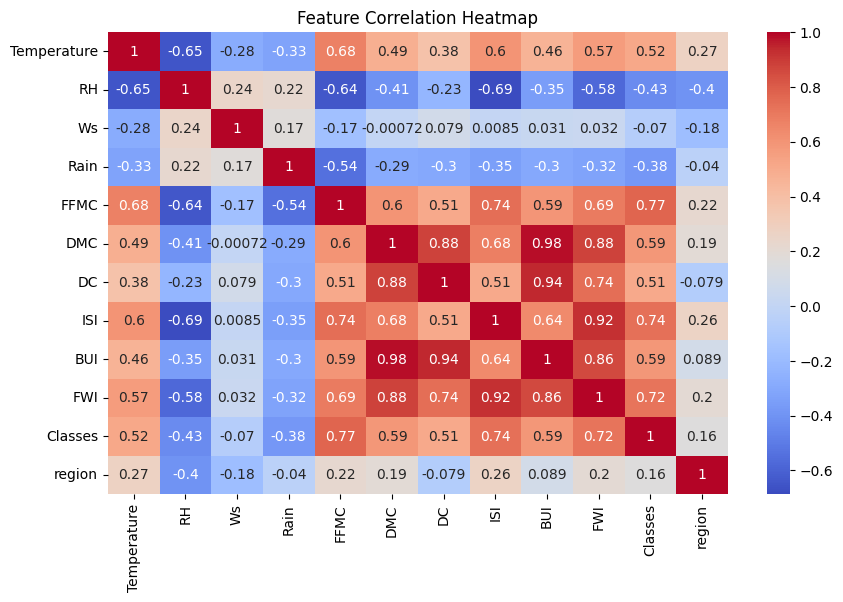

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

1: TEMPERATURE 
POSITVE CORR: FFMC ISI 
NEAGTIVE CORR: RH WS RAIN 
MODERATE: DMC DC BUI FWI CLASSES 
2: RH
+ = NONE 
-= ALL EXCEPT  WS AND RAIN
3: RAIN 
ALL NEAGTIVE CORRELATION


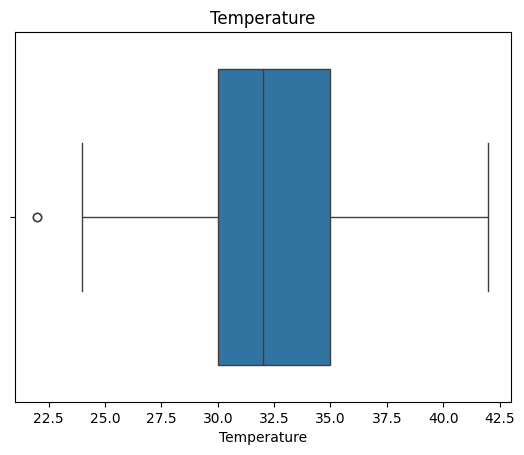

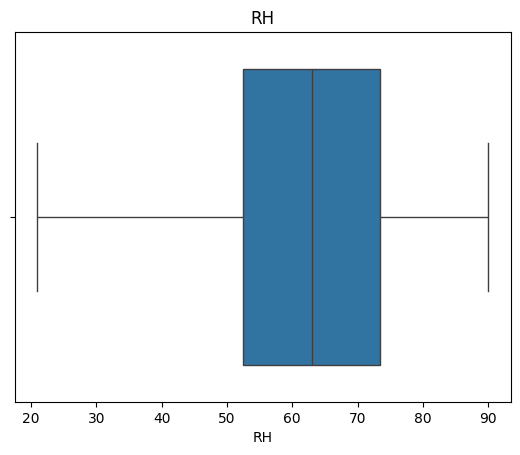

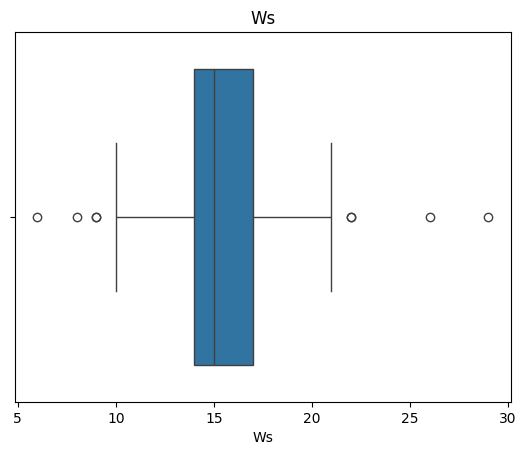

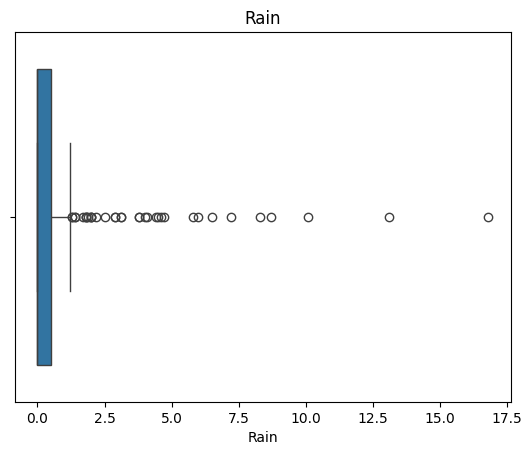

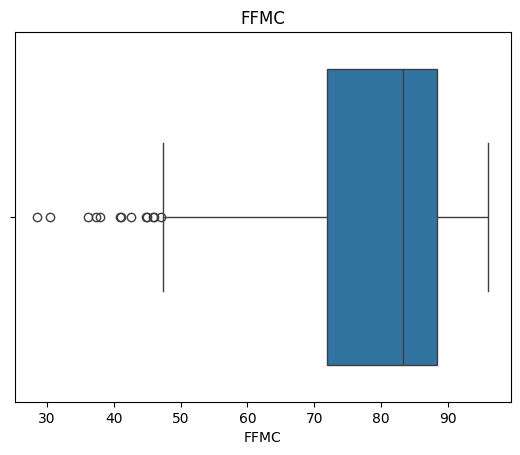

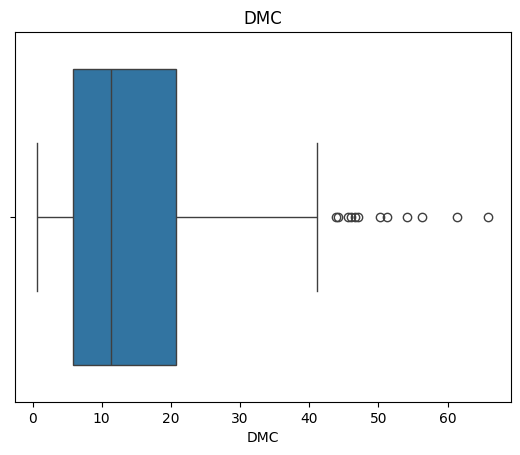

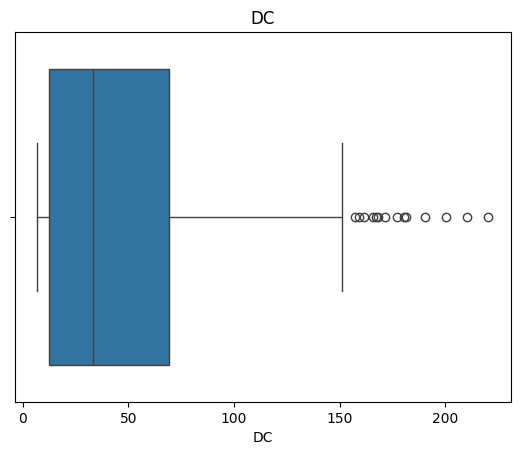

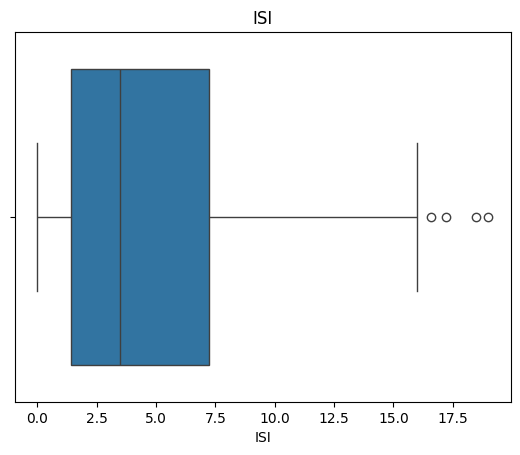

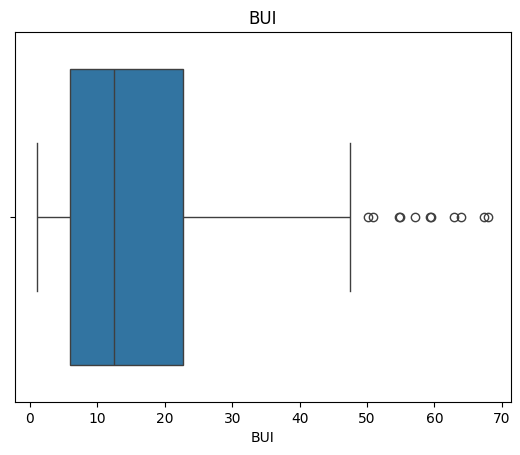

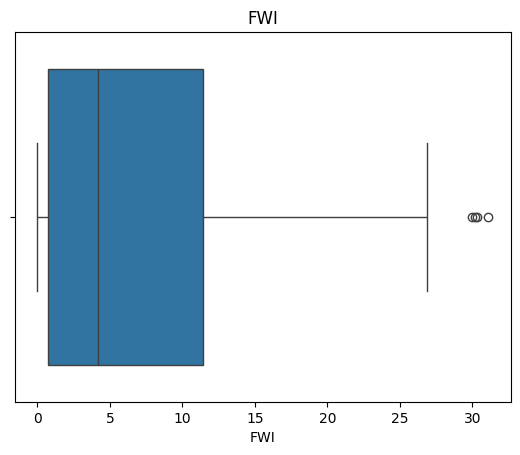

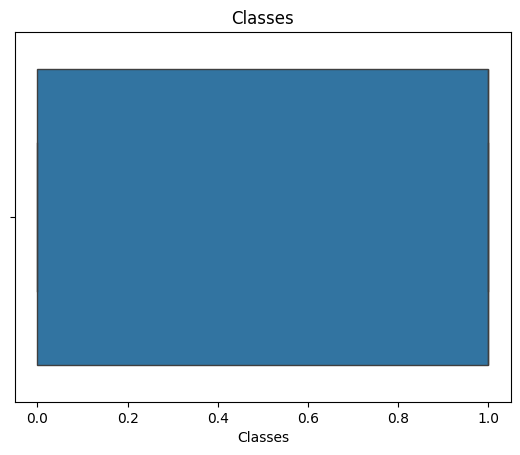

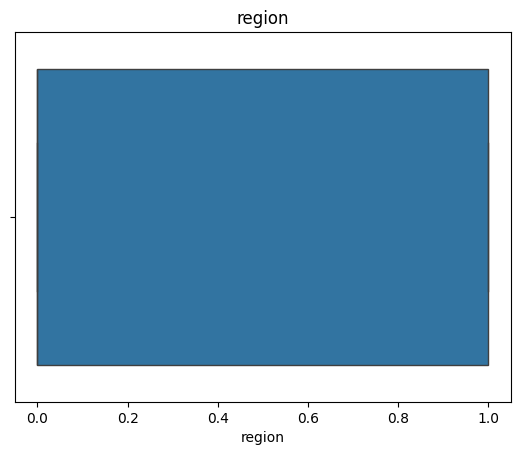

In [ ]:
## NOW WE ARE CHECKING THE OUTLIERS 


for col in df.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"Outliers in {col}:")
    print(outliers[col])
    print("------------")

Outliers in Temperature:
93     22
105    22
Name: Temperature, dtype: int64
------------
Outliers in RH:
Series([], Name: RH, dtype: int64)
------------
Outliers in Ws:
2      22
52     22
105    26
178     9
201     9
234     8
239     6
243    29
Name: Ws, dtype: int64
------------
Outliers in Rain:
1       1.3
2      13.1
3       2.5
14      3.1
38      1.4
91     16.8
92      7.2
93     10.1
94      3.8
101     1.8
102     1.8
104     4.6
105     8.3
116     5.8
120     1.8
121     1.4
125     4.0
126     2.0
131     1.3
136     2.0
140     4.7
141     8.7
142     4.5
153     1.7
154     2.2
161     6.0
162     1.9
163     3.8
164     2.9
190     3.1
191     2.9
220     4.1
221     6.5
239     2.0
242     4.4
Name: Rain, dtype: float64
------------
Outliers in FFMC:
2      47.1
3      28.6
15     36.1
16     37.3
92     46.0
93     30.5
94     42.6
104    40.9
106    44.9
121    45.0
216    37.9
242    41.1
243    45.9
Name: FFMC, dtype: float64
------------
Outliers in DMC:
85   

FEATURE SELECTION PART 

In [ ]:
## independent and dependent feature 
X=df.drop('FWI',axis=1)
y=df['FWI']

In [ ]:
## train test split 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=42)

In [ ]:
# FETURE SELECTION USING COORELATION 
X_train.shape
X_test.shape


(61, 11)

<Axes: >

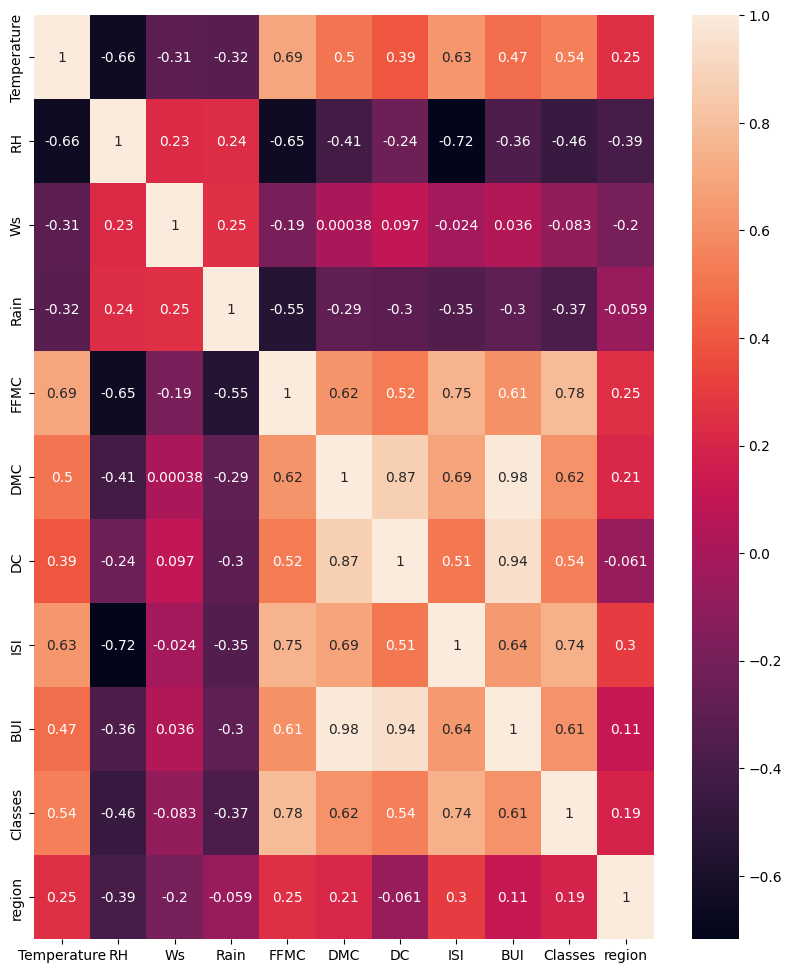

In [ ]:
## checking for multicolinaer
plt.figure(figsize=(10,12))
corr=X_train.corr()
sns.heatmap(corr,annot=True)



In [ ]:
# now we remove the feature which are highly correlated
def correlation(df, threshold):
    col_corr = set()   # set to store correlated columns
    corr_matrix = df.corr()
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]   # get column name
                col_corr.add(colname)
    
    return col_corr

In [ ]:
## threshold 

corr_feature=correlation(X_train,0.90)

In [ ]:
#3 drop the feature which have a corr more than 95
import numpy as np 
import pandas as pd
X_train.drop(corr_feature,axis=1,inplace=True)
X_test.drop(corr_feature,axis=1,inplace=True)


In [ ]:
X_train.shape
X_test.shape



(61, 10)

In [ ]:
## NOW WE WILL DO THE STANDARDIZATION 


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select features

# Fit and transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
X_train_scaled.shape

NameError: name 'X_train_scaled' is not defined

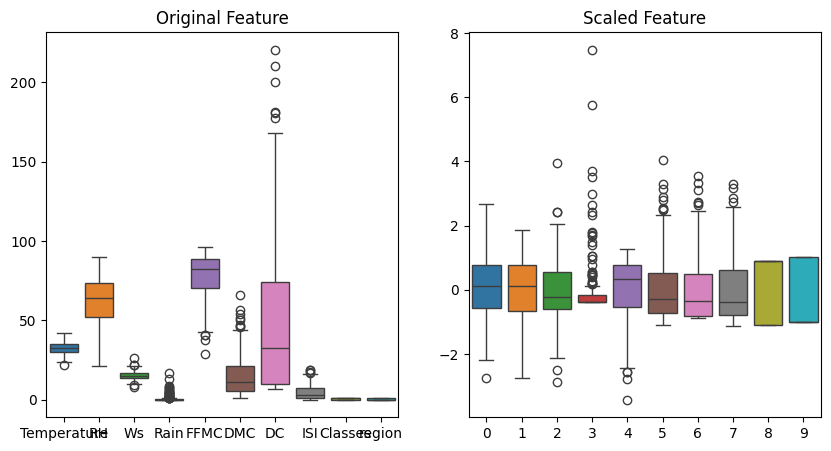

In [ ]:
## BOX PLOT TO UNDERSTAND EFFECT OF STANDARDIZATION 


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("Original Feature")

plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("Scaled Feature")

plt.show()

MODEL TRAINING 

## LINEAR REGRESSION


In [ ]:
from sklearn.linear_model import LinearRegression
linear =LinearRegression()
## now this is oure model 
linear.fit(X_train_scaled,y_train)
y_train_pred=linear.predict(X_train_scaled)
y_test_pred=linear.predict(X_test_scaled)
## now importing all thee error matrices 
## Performance metrix 
from sklearn.metrics import mean_absolute_error,mean_squared_error
RME=mean_squared_error(y_test,y_test_pred)
RAE=mean_absolute_error(y_test,y_test_pred)
rmse=np.sqrt(RME)
print(" RME IS", RME)
print("RAE is",RAE)
print("RMSE",rmse)
## now calculating the R2
from sklearn.metrics import r2_score
score1= r2_score(y_train,y_train_pred)
score=r2_score(y_test, y_test_pred)
print(score*100)
print(score1*100)


 RME IS 0.7499258036691263
RAE is 0.5170107980662408
RMSE 0.8659825654533273
98.30565611009445
97.19104834407162


In [ ]:
## residuals 
residue = y_test-y_test_pred

In [ ]:
print(residue)

24     0.124636
6     -0.358596
154    0.576599
235   -1.187081
241   -0.158176
         ...   
164    0.163220
181    0.123721
227    0.200778
233    0.697456
156    0.073740
Name: FWI, Length: 61, dtype: float64


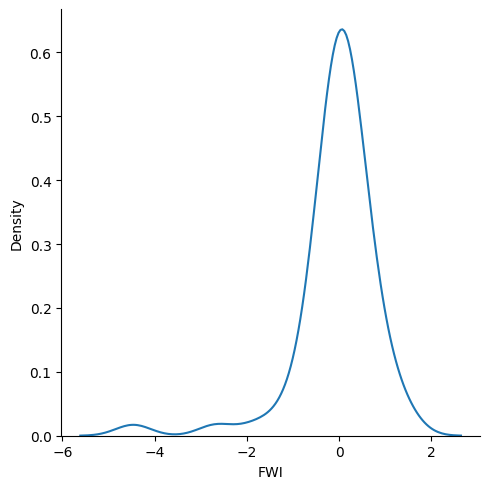

In [ ]:
## plot the residuals 
sns.displot(residue,kind='kde')

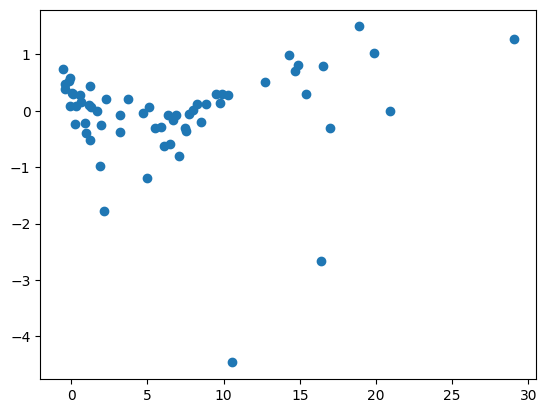

In [ ]:
## scatter plot with respect to prediction and residuals 
plt.scatter(y_test_pred,residue)

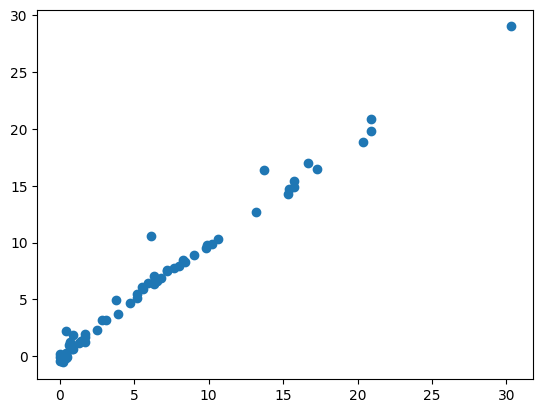

In [ ]:
## plot the y_test and the y_pred
plt.scatter(y_test,y_test_pred)

RIDGE AND LASSO 

In [ ]:
from sklearn.linear_model import Lasso
lasso =Lasso()
## now this is oure model 
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
## now importing all thee error matrices 
## Performance metrix 
from sklearn.metrics import mean_absolute_error,mean_squared_error
RME=mean_squared_error(y_test,y_pred)
RAE=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(RME)
print(" RME IS", RME)
print("RAE is",RAE)
print("RMSE",rmse)
## now calculating the R2
from sklearn.metrics import r2_score
score=r2_score(y_test, y_pred)
print(score*100)


 RME IS 2.2177558134104585
RAE is 1.1257992990774726
RMSE 1.4892131524434165
94.98931628519823


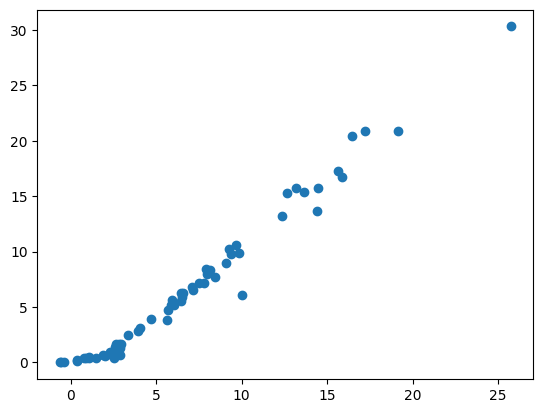

In [ ]:
plt.scatter(y_pred,y_test)

RIDGE REGRESSION


In [ ]:
from sklearn.linear_model import Ridge
ridge =Ridge()
## now this is oure model 
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
## now importing all thee error matrices 
## Performance metrix 
from sklearn.metrics import mean_absolute_error,mean_squared_error
RME=mean_squared_error(y_test,y_pred)
RAE=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(RME)
print(" RME IS", RME)
print("RAE is",RAE)
print("RMSE",rmse)
## now calculating the R2
from sklearn.metrics import r2_score
score=r2_score(y_test, y_pred)
print(score*100)


 RME IS 0.7787557734922156
RAE is 0.5292519766274832
RMSE 0.8824714009486174
98.2405191552425


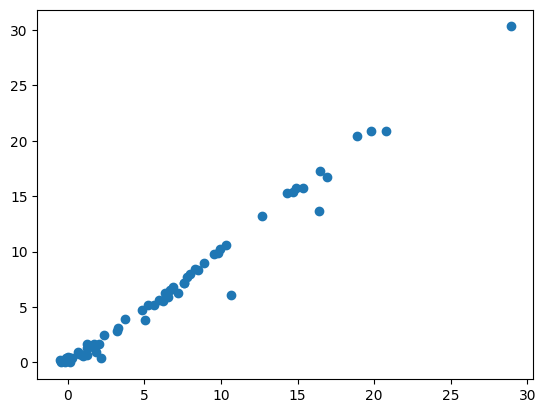

In [ ]:
plt.scatter(y_pred,y_test)

ELASTIC NET REGRESSION

In [ ]:
from sklearn.linear_model import ElasticNet
Net =Ridge()
## now this is oure model 
Net.fit(X_train_scaled,y_train)
y_train_pred=Net.predict(X_train_scaled)
y_test_pred=Net.predict(X_test_scaled)
## now importing all thee error matrices 
## Performance metrix 
from sklearn.metrics import mean_absolute_error,mean_squared_error
RME=mean_squared_error(y_test,y_test_pred)
RAE=mean_absolute_error(y_test,y_test_pred)
rmse=np.sqrt(RME)
print(" RME IS", RME)
print("RAE is",RAE)
print("RMSE",rmse)
## now calculating the R2
from sklearn.metrics import r2_score
score=r2_score(y_test, y_test_pred)
print(score*100)


 RME IS 0.7787557734922156
RAE is 0.5292519766274832
RMSE 0.8824714009486174
98.2405191552425


In [ ]:
## chekcing the overfitting conditon 
from sklearn.metrics import r2_score
##Check how well the model learned the training data
train_r2 = r2_score(y_train, y_train_pred)
##Check how well the model works on new unseen data
test_r2 = r2_score(y_test, y_test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9718568292336821
Test R2: 0.9824051915524249


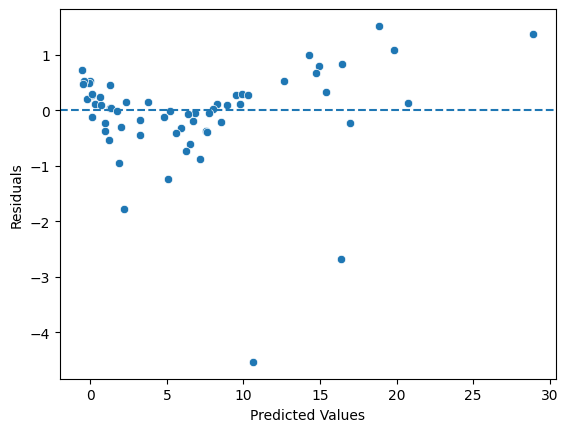

In [ ]:
## if the plot are scattered around the 0 then it is said to be good model 
# and if the hist plot is around the 0 and from the bell curved then it is also a good model 
residuals = y_test - y_test_pred

sns.scatterplot(x=y_test_pred, y=residuals)

plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

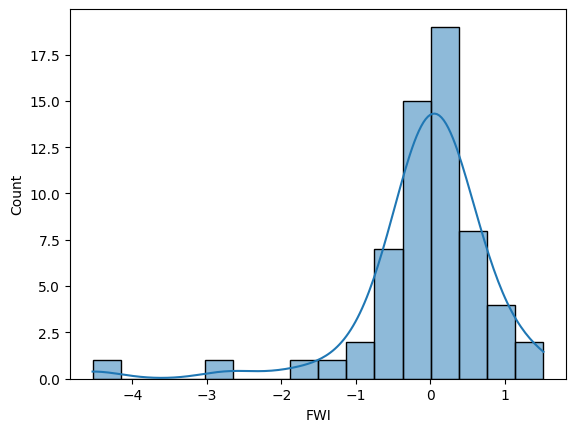

In [ ]:
sns.histplot(residuals, kde=True)
plt.show()


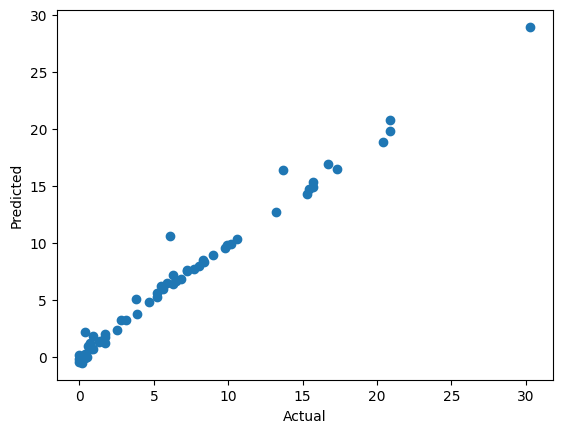

In [ ]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

CROSS VALIDATION LASSO

In [ ]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)



,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [ ]:
lassocv.alpha_

np.float64(0.05725391318234408)

In [ ]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

98.2405191552425


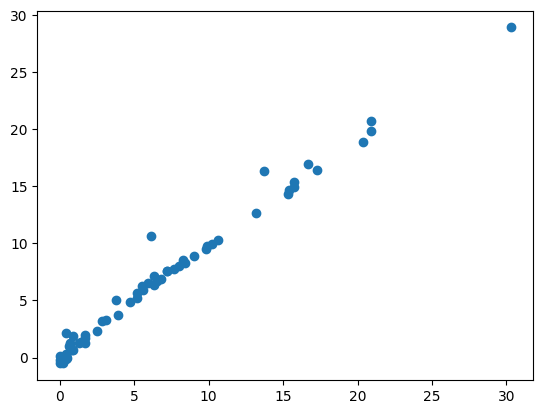

In [ ]:
lassocv.predict(X_test_scaled)
score=r2_score(y_test,y_pred)
print(score*100)
plt.scatter(y_test,y_pred)


PICKLING THE MODEL


In [ ]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [ ]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [ ]:
import pickle

pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(ridge, open('ridge.pkl', 'wb'))